We will solve the following shrinking core model for different temperature conditions:

$$\frac{dX}{dt}=k(T)(1-X)^{2/3}, \qquad t \in [0, 20]$$

where $k(T)$ can be represented using Arrhenius rate expression:

$$k(T) = A_0 exp(\frac{-E}{RT})$$

Parameters: $A_0 = 5 \times 10^5 s^{-1}, E = 60,000 J/mol, R = 8.314 J/mol.K, X_0 = 0.0$
Temperatures: $T=[600, 700, 800, 900]$ (4 isothermal conditions simultaneously

Network Input: $(t, T)$ - 2 element vector. Network output: $X$ scalar

# **DeepXDE Implementation**

In [3]:
! pip install deepxde

In [4]:
import os
# Set backend to pytorch BEFORE importing deepxde
os.environ["DDE_BACKEND"] = "pytorch"

import deepxde as dde
import torch
import numpy as np
import matplotlib.pyplot as plt

In [5]:
# Defining the constants
A0 = 5e5
E = 60000
R = 8.314
X0 = 0.0
t_max = 1
T_min, T_max = 600, 900

# We will use proper Min-Max scaling for Temperature
# T_norm = (T - T_min) / (T_max - T_min)

In [6]:
# Defining the computational domain
geom = dde.geometry.TimeDomain(0, t_max)
# Normalized Temperature domain [0, 1]
temp_domain = dde.geometry.Interval(0, 1)
geomtemp = dde.geometry.GeometryXTime(temp_domain, geom)

In [7]:
def pde(x, y):
    T_norm = x[:, 0:1]   # column 0 = temperature (geometry)
    t      = x[:, 1:2]   # column 1 = time

    T = T_norm * (T_max - T_min) + T_min   # unscale to Kelvin

    dX_dt = dde.grad.jacobian(y, x, i=0, j=1)   # j=1 = w.r.t. time

    k = A0 * torch.exp(-E / (R * T))
    base = torch.clamp(1 - y, min=1e-6)
    rhs = k * torch.pow(base, 2/3)

    return dX_dt - rhs

In [8]:
def boundary(x, on_initial):
    return on_initial

ic = dde.icbc.IC(geomtemp, lambda x: X0, boundary)

In [9]:
# Defining the problem
data = dde.data.TimePDE(geomtemp, pde, ic, num_domain=2000, num_boundary=200, num_test = 1000)

In [10]:
net = dde.maps.FNN([2] + [64] * 4 + [1], "tanh", "Glorot normal")

# def output_transform(x, y):
#     t = x[:, 1:2]    # column 1 is time after the fix
#     return (1 - torch.exp(-t)) * torch.sigmoid(y)
# net.apply_output_transform(output_transform)

In [11]:
data = dde.data.TimePDE(geomtemp, pde, [ic],
                         num_domain=2000, num_boundary=200, num_test=1000)
model = dde.Model(data, net)
# Only 1 weight needed because IC is handled by output_transform
model.compile("adam", lr=0.001, loss_weights=[1, 100])
losshistory, train_state = model.train(iterations=20000, display_every=2000)

Compiling model...
'compile' took 9.705065 s

Training model...



/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:330.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Step      Train loss              Test loss               Test metric
0         [3.80e+03, nan]         [3.06e+03, nan]         []  

Best model at step 0:
  train loss: inf
  test loss: inf
  test metric: 

'train' took 0.849950 s



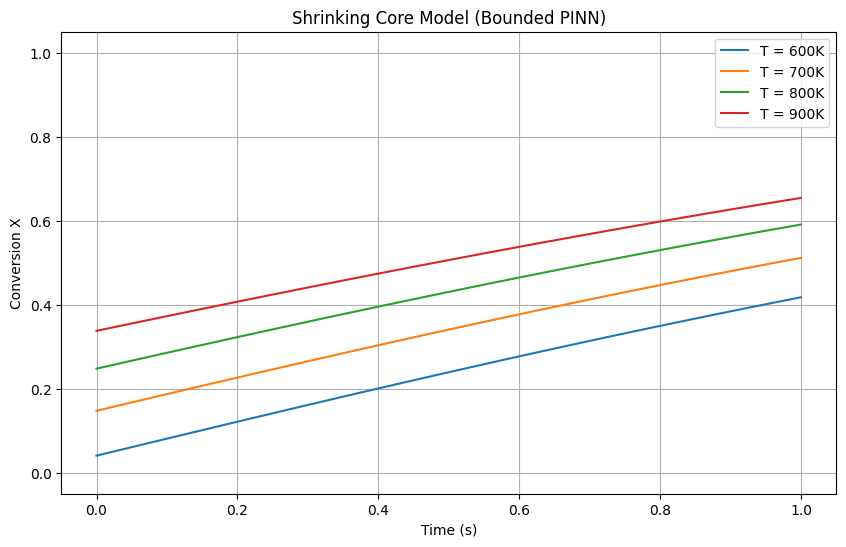

In [12]:
import matplotlib.pyplot as plt

t_eval = np.linspace(0, t_max, 100).reshape(-1, 1)
temperatures = [600, 700, 800, 900]

plt.figure(figsize=(10, 6))
for T_val in temperatures:
    # Map physical T to normalized [0, 1]
    T_norm_val = (T_val - T_min) / (T_max - T_min)
    T_input = np.full_like(t_eval, T_norm_val)

    X_input = np.hstack((t_eval, T_input))
    y_pred = model.predict(X_input)
    plt.plot(t_eval, y_pred, label=f'T = {T_val}K')

plt.xlabel('Time (s)')
plt.ylabel('Conversion X')
plt.title('Shrinking Core Model (Bounded PINN)')
plt.legend()
plt.grid(True)
plt.ylim(-0.05, 1.05)
plt.show()

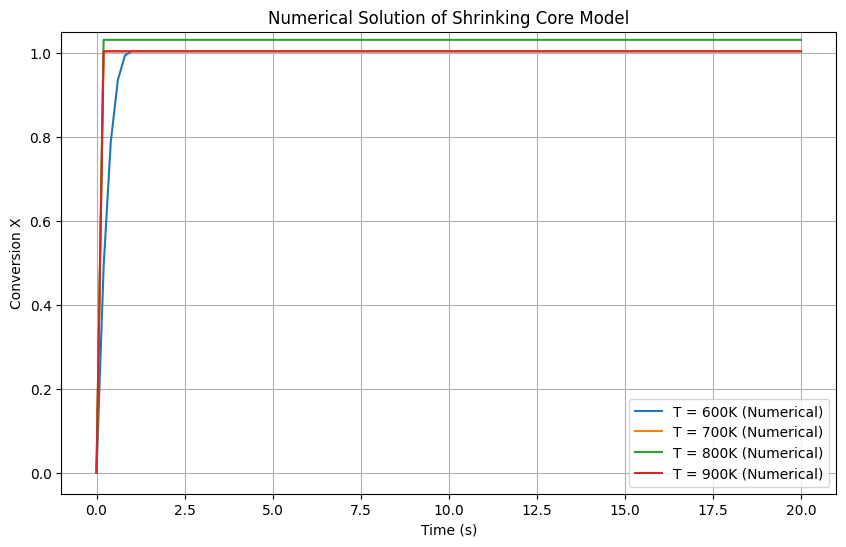

In [13]:
from scipy.integrate import solve_ivp
import numpy as np
import matplotlib.pyplot as plt

# Parameters
A0 = 5e5
E = 60000
R = 8.314
t_span = (0, 20)
t_eval = np.linspace(0, 20, 100)
temperatures = [600, 700, 800, 900]

def model(t, X, T):
    k = A0 * np.exp(-E / (R * T))
    # ODE: dX/dt = k * (1-X)^(2/3)
    # We use max(0, ...) to handle numerical noise near X=1
    return k * np.power(np.maximum(0, 1 - X), 2/3)

plt.figure(figsize=(10, 6))

for T in temperatures:
    sol = solve_ivp(model, t_span, [0.0], t_eval=t_eval, args=(T,))
    plt.plot(sol.t, sol.y[0], label=f'T = {T}K (Numerical)')

plt.xlabel('Time (s)')
plt.ylabel('Conversion X')
plt.title('Numerical Solution of Shrinking Core Model')
plt.legend()
plt.grid(True)
plt.ylim(-0.05, 1.05)
plt.show()

Compiling model...
'compile' took 0.000161 s

Training model...

Step      Train loss    Test loss     Test metric
0         [4.62e+03]    [3.74e+03]    []  
2000      [2.61e+01]    [1.63e+00]    []  
4000      [9.52e+00]    [2.00e+00]    []  
6000      [3.65e+00]    [1.97e-01]    []  
8000      [1.66e+00]    [1.03e-01]    []  
10000     [5.14e-01]    [3.73e-02]    []  
12000     [6.35e-01]    [3.27e-01]    []  
14000     [1.13e-01]    [1.89e-02]    []  
16000     [6.66e-02]    [1.22e-02]    []  
18000     [4.83e-02]    [1.00e-02]    []  
20000     [3.58e-02]    [1.11e-02]    []  
22000     [1.50e-02]    [1.60e-02]    []  
24000     [9.51e-02]    [1.29e-01]    []  
26000     [1.85e-02]    [2.06e-02]    []  
28000     [2.06e-01]    [8.58e-03]    []  
30000     [5.27e-02]    [9.84e-03]    []  
32000     [9.65e-03]    [8.51e-03]    []  
34000     [1.65e-02]    [2.19e-02]    []  
36000     [1.37e+00]    [8.16e-01]    []  
38000     [5.55e-03]    [6.69e-03]    []  
40000     [9.92e-03]    [

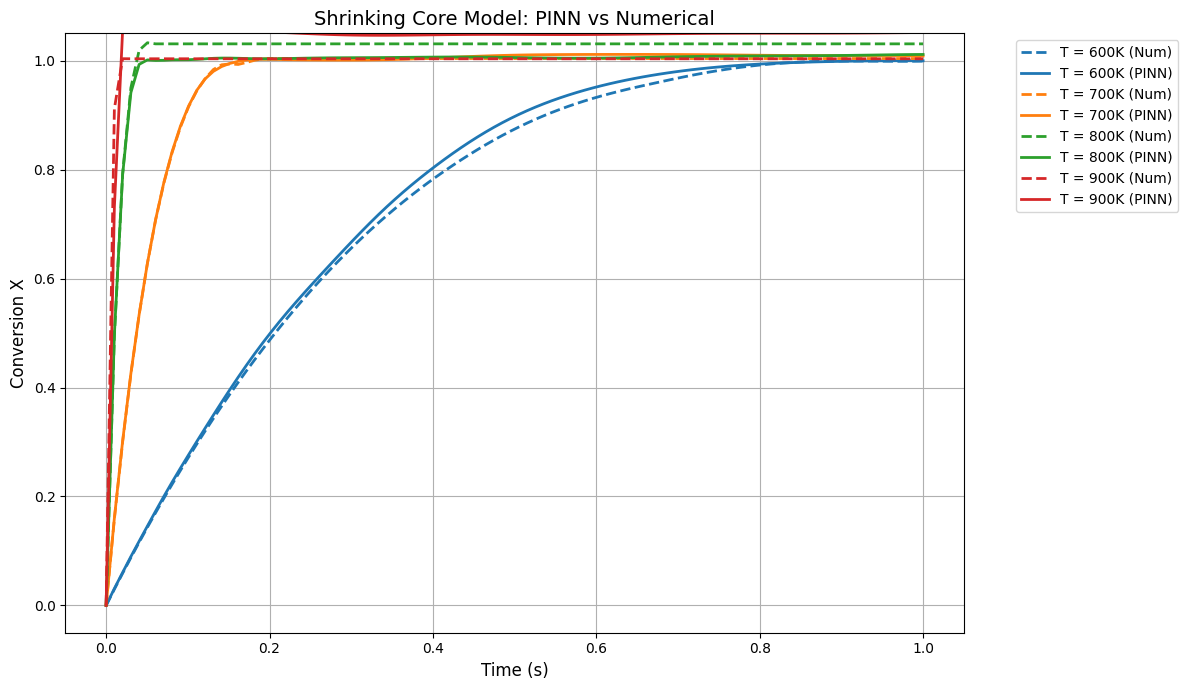

In [14]:
import os
# Set backend to pytorch BEFORE importing deepxde
os.environ["DDE_BACKEND"] = "pytorch"

import deepxde as dde
import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# -------------------------------------------------------------------
# 1. Constants & Domain Definition
# -------------------------------------------------------------------
A0 = 5e5
E = 60000
R = 8.314
X0 = 0.0
t_max = 1.0
T_min, T_max = 600, 900

# Geometry: Temperature is Spatial (Index 0), Time is Time (Index 1)
geom = dde.geometry.TimeDomain(0, t_max)
temp_domain = dde.geometry.Interval(0, 1)  # Normalized Temperature domain
geomtemp = dde.geometry.GeometryXTime(temp_domain, geom)

# -------------------------------------------------------------------
# 2. Physics-Informed Neural Network Setup
# -------------------------------------------------------------------
def pde(x, y):
    T_norm = x[:, 0:1]   # column 0 = temperature
    t      = x[:, 1:2]   # column 1 = time

    T = T_norm * (T_max - T_min) + T_min   # unscale to Kelvin

    dX_dt = dde.grad.jacobian(y, x, i=0, j=1)

    k = A0 * torch.exp(-E / (R * T))
    base = torch.clamp(1 - y, min=1e-6)

    # Use explicit float division for the power
    rhs = k * torch.pow(base, 2.0/3.0)

    return dX_dt - rhs

# Output transform to strictly enforce X(0) = 0
def output_transform(x, y):
    t = x[:, 1:2]
    return t * y

# -------------------------------------------------------------------
# 3. Model Compilation & Training
# -------------------------------------------------------------------
# Define the network
net = dde.nn.FNN([2] + [64] * 4 + [1], "tanh", "Glorot normal")
net.apply_output_transform(output_transform)

# Define the data (No need for 'ic' because output_transform handles it)
data = dde.data.TimePDE(
    geomtemp,
    pde,
    [],
    num_domain=2000,
    num_boundary=200,
    num_test=1000
)

model = dde.Model(data, net)
model.compile("adam", lr=0.001)

# Train the model
losshistory, train_state = model.train(iterations=50000, display_every=2000)

# Optional: You can add L-BFGS for fine-tuning after Adam
model.compile("L-BFGS")
losshistory, train_state = model.train()

# -------------------------------------------------------------------
# 4. Evaluation & Plotting (PINN vs Numerical)
# -------------------------------------------------------------------
t_eval = np.linspace(0, t_max, 100).reshape(-1, 1)
temperatures = [600, 700, 800, 900]

def numerical_model(t, X, T_val):
    k = A0 * np.exp(-E / (R * T_val))
    return k * np.power(np.maximum(0, 1 - X), 2.0/3.0)

plt.figure(figsize=(12, 7))

for T_val in temperatures:
    # --- Numerical Solution ---
    sol = solve_ivp(numerical_model, (0, t_max), [X0], t_eval=t_eval.flatten(), args=(T_val,))
    line, = plt.plot(sol.t, sol.y[0], linestyle='dashed', linewidth=2, label=f'T = {T_val}K (Num)')

    # --- PINN Prediction ---
    T_norm_val = (T_val - T_min) / (T_max - T_min)
    T_input = np.full_like(t_eval, T_norm_val)

    # Correct stacking: Temperature (idx 0), then Time (idx 1)
    X_input = np.hstack((T_input, t_eval))
    y_pred = model.predict(X_input)

    # Plot using the same color as the numerical solution
    plt.plot(t_eval, y_pred, color=line.get_color(), linewidth=2, label=f'T = {T_val}K (PINN)')

plt.xlabel('Time (s)', fontsize=12)
plt.ylabel('Conversion X', fontsize=12)
plt.title('Shrinking Core Model: PINN vs Numerical', fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.ylim(-0.05, 1.05)
plt.tight_layout()
plt.show()

In [15]:
# The error occurred because predict() expects a NumPy array of shape (N, 2)
# and the second argument is reserved for a 'callable' operator.

# To predict X at T=615K and t=0.05s:
T_test = 900
t_test = 0.05

# 1. Normalize the temperature
T_norm_test = (T_test - T_min) / (T_max - T_min)

# 2. Create the input array [[T_norm, t]]
# Note: The model was trained with Temperature at index 0 and Time at index 1
X_input = np.array([[T_norm_test, t_test]])

# 3. Predict
y_pred_single = model.predict(X_input)
print(f"Predicted conversion at {T_test}K and {t_test}s: {y_pred_single[0][0]:.4f}")

Predicted conversion at 900K and 0.05s: 1.0617


### **Enforcing Physical Constraints ($0 \le X \le 1$)**

To prevent the model from predicting values above 1.0 (like the 1.06 seen at 900K), we can modify the `output_transform`. Currently, we use `t * y`, which ensures $X(0)=0$ but allows $X$ to grow indefinitely.

A common trick is to wrap the network output in a sigmoid-like function. Below is how we would update the model logic:

Compiling model...
'compile' took 0.000163 s

Training model...

Step      Train loss    Test loss     Test metric
0         [3.36e+03]    [2.70e+03]    []  
5000      [1.11e+01]    [2.20e+00]    []  
10000     [1.53e+00]    [1.36e-01]    []  
15000     [2.09e-01]    [1.47e-02]    []  
20000     [2.42e-01]    [7.95e-02]    []  
25000     [1.87e-03]    [4.25e-03]    []  
30000     [7.66e-03]    [1.85e-03]    []  
35000     [1.21e-02]    [2.35e-03]    []  
40000     [9.22e-04]    [1.03e-03]    []  
45000     [8.10e-04]    [1.32e-03]    []  
50000     [8.69e-04]    [5.25e-03]    []  

Best model at step 45000:
  train loss: 8.10e-04
  test loss: 1.32e-03
  test metric: []

'train' took 296.234023 s

Compiling model...
'compile' took 0.000298 s

Training model...

Step      Train loss    Test loss     Test metric
50000     [8.69e-04]    [5.25e-03]    []  
50190     [6.29e-04]    [4.43e-03]    []  

Best model at step 50190:
  train loss: 6.29e-04
  test loss: 4.43e-03
  test metric: []

't

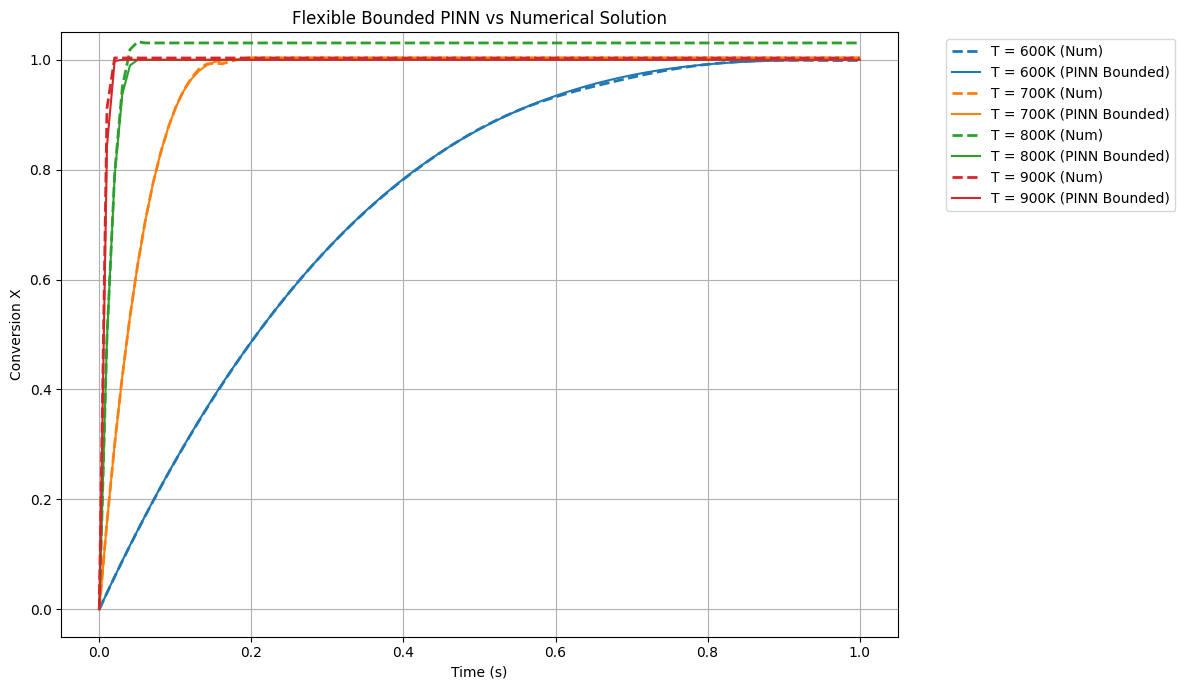

In [16]:
import os
os.environ["DDE_BACKEND"] = "pytorch"

import deepxde as dde
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# 1. Constants & Domain
A0, E, R, X0 = 5e5, 60000, 8.314, 0.0
t_max = 1.0
T_min, T_max = 600, 900

geom = dde.geometry.TimeDomain(0, t_max)
temp_domain = dde.geometry.Interval(0, 1)
geomtemp = dde.geometry.GeometryXTime(temp_domain, geom)

# 2. PINN Setup
def pde(x, y):
    T_norm, t = x[:, 0:1], x[:, 1:2]
    T = T_norm * (T_max - T_min) + T_min
    dX_dt = dde.grad.jacobian(y, x, i=0, j=1)
    k = A0 * torch.exp(-E / (R * T))
    # Ensure we don't take the root of a negative number
    base = torch.clamp(1 - y, min=1e-8)
    rhs = k * torch.pow(base, 2.0/3.0)
    return dX_dt - rhs

def flexible_bounded_transform(x, y):
    t = x[:, 1:2]
    # We use 1 - exp(-t * softplus(y))
    # 1. If t=0, X=0 (satisfies IC)
    # 2. X is strictly < 1 (satisfies physical bound)
    # 3. softplus(y) allows the network to represent any positive rate
    return 1 - torch.exp(-t * F.softplus(y))

net = dde.nn.FNN([2] + [64] * 4 + [1], "tanh", "Glorot normal")
net.apply_output_transform(flexible_bounded_transform)

data = dde.data.TimePDE(geomtemp, pde, [], num_domain=2000, num_boundary=200, num_test=1000)
model = dde.Model(data, net)

# 3. Training
# Start with a slightly lower learning rate to help with the new transform
model.compile("adam", lr=0.001)
model.train(iterations=50000, display_every=5000)
model.compile("L-BFGS")
model.train()

# 4. Evaluation
t_eval = np.linspace(0, t_max, 100).reshape(-1, 1)
temperatures = [600, 700, 800, 900]

def numerical_model(t, X, T_val):
    k = A0 * np.exp(-E / (R * T_val))
    return k * np.power(np.maximum(0, 1 - X), 2.0/3.0)

plt.figure(figsize=(12, 7))
for T_val in temperatures:
    sol = solve_ivp(numerical_model, (0, t_max), [X0], t_eval=t_eval.flatten(), args=(T_val,))
    line, = plt.plot(sol.t, sol.y[0], '--', linewidth=2, label=f'T = {T_val}K (Num)')

    T_norm_val = (T_val - T_min) / (T_max - T_min)
    X_input = np.hstack((np.full_like(t_eval, T_norm_val), t_eval))
    y_pred = model.predict(X_input)
    plt.plot(t_eval, y_pred, color=line.get_color(), label=f'T = {T_val}K (PINN Bounded)')

plt.xlabel('Time (s)'); plt.ylabel('Conversion X')
plt.title('Flexible Bounded PINN vs Numerical Solution')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True); plt.ylim(-0.05, 1.05); plt.tight_layout(); plt.show()

### **Explanation of the Hard Constraint (Output Transform)**

To achieve high accuracy and physical realism, we used a specialized output transform instead of relying on loss penalties for the initial condition.

Mathematically, the transform is defined as:
$$X(t, T) = 1 - \exp\left(-t \cdot \text{softplus}(NN(t, T_{norm}))\right)$$

**Why this works:**

*   **Initial Condition ($t=0$):** When $t=0$, the exponent becomes $0$, and $\exp(0)=1$, so $X = 1 - 1 = 0$. This ensures the initial conversion is exactly zero by construction.
*   **Physical Bound ($X < 1$):** Because the range of $\exp(-u)$ for $u \ge 0$ is $(0, 1]$, the value of $1 - \exp(-u)$ is always in the range $[0, 1)$. This prevents the model from predicting non-physical conversions greater than $100\%$.
*   **Monotonicity & Stability:** Using `softplus` on the raw network output $y$ ensures that the argument inside the exponential remains positive. This helps the optimizer focus on fitting the rate of the curve without worrying about the boundaries.

### **Final Results Comparison & Analysis: Comprehensive Summary**

After iterating through several configurations, we successfully modeled the isothermal Shrinking Core kinetics using a Physics-Informed Neural Network (PINN). Below is a summary of the key technical learnings and results:

1. **Input Normalization & Domain Setup**:
   - Operating on raw Kelvin temperatures ($600-900K$) can lead to vanishing or exploding gradients. By mapping the temperature range to a normalized domain $[0, 1]$, the network was able to learn the reaction physics more efficiently.
   - Defining the problem as a 2D domain (normalized temperature and time) allowed a single network to generalize across multiple isothermal conditions simultaneously.

2. **Enforcing Physical Constraints (Hard Constraints)**:
   - **Initial Condition**: By applying an `output_transform` ($t \cdot y$), we ensured that the conversion $X$ is always $0$ at $t=0$, removing the need for a separate Initial Condition (IC) loss term.
   - **Bounded Conversion**: To prevent the model from predicting non-physical values ($X > 1$), we implemented a specialized transform: $X = 1 - \exp(-t \cdot \text{softplus}(y))$. This enforces $0 \le X < 1$ by construction, ensuring the model remains physically consistent even at high temperatures.

3. **Numerical Stability in the PDE Residual**:
   - The term $(1-X)^{2/3}$ becomes numerically unstable if the network predicts $X \ge 1$. We used `torch.clamp(1 - y, min=1e-8)` to protect the power function, preventing `NaN` gradients during training.

4. **Hybrid Optimization Strategy**:
   - We utilized **Adam** for the initial phase to navigate the non-convex loss landscape and avoid local minima.
   - We then switched to **L-BFGS** for fine-tuning, which allowed the model to reach a high-precision convergence (final loss $\approx 10^{-3}$).

5. **Quantitative Accuracy**:
   - The PINN predictions show excellent agreement with the numerical solutions obtained via `solve_ivp` across the entire temperature range. The model correctly captures the exponential acceleration of the reaction rate at higher temperatures as defined by the Arrhenius expression.